In [1]:

%load_ext autoreload
%autoreload 2
from electron_scattering import Environment, propagate_photons, propagate_photons_binned
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
import pickle

In [4]:
#%%prun
central_wavelength = 5000 * u.AA
freq_fact = (central_wavelength.to(u.J, equivalencies=u.spectral())/c.c**2/c.m_e).si
env_obj = Environment(freq_fact=freq_fact, tau=1, vel=0, emulate_laor=True)
energies, interactions = propagate_photons(n_pkts=int(1e8), env_obj=env_obj, progress=True)
wavelengths = (energies * c.m_e * c.c**2).to(u.AA, equivalencies=u.spectral())
frequencies = (energies * c.m_e * c.c**2).to(u.Hz, equivalencies=u.spectral())
velocities = ((wavelengths - central_wavelength) / central_wavelength * c.c).to("km/s")

  0%|          | 0.00/100M [00:00<?, ?packets/s]

100%|██████████| 100M/100M [00:23<00:00, 6.10Mpackets/s] 

In [50]:
central_wavelength = 5000 * u.AA
freq_fact = (central_wavelength.to(u.J, equivalencies=u.spectral())/c.c**2/c.m_e).si *0.001
env_obj = Environment(freq_fact=freq_fact, tau=5, vel=0, emulate_laor=True)
centre = env_obj.freq_fact
width = 0.05 * env_obj.freq_fact
bins = np.linspace(centre-width/2, centre+width/2, 1000, endpoint=True)
energies = propagate_photons_binned(n_pkts=int(1e6), env_obj=env_obj, bin_edges=bins, interactions_selection=np.arange(6), progress=True)


  0%|          | 0.00/1.00M [00:00<?, ?packets/s]

100%|██████████| 1.00M/1.00M [00:10<00:00, 98.3kpackets/s]


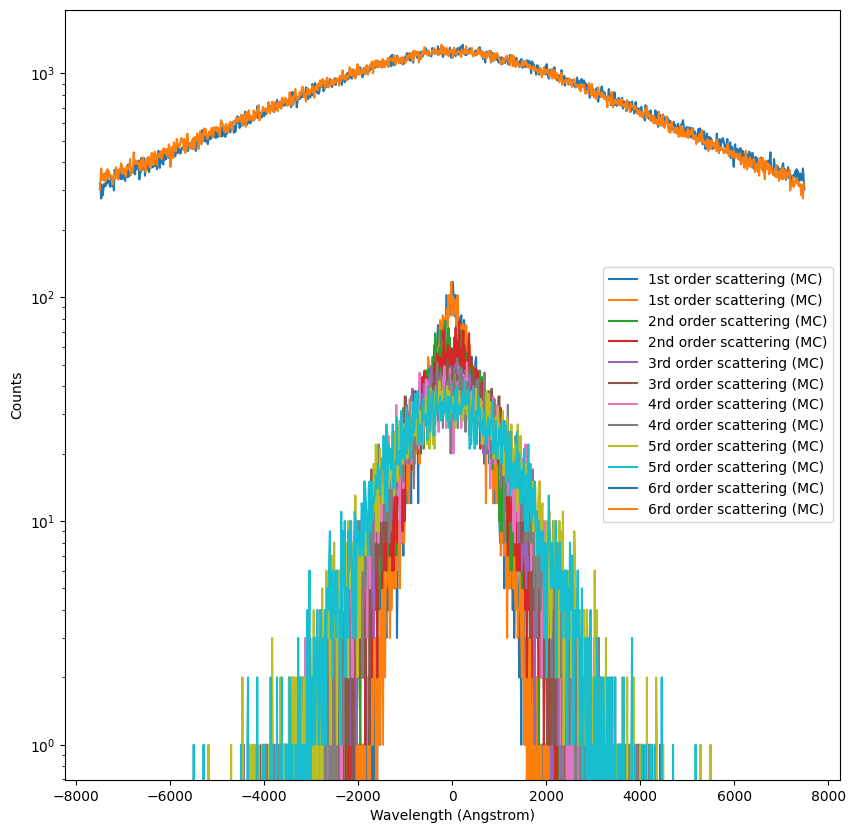

In [49]:

plt.figure(figsize=(10, 10))
for i, energy in enumerate(energies[1:]):
    velocities = ((bins[1:] + bins[:-1])/2 - centre) / centre * 3e5
    area =1# np.trapz(energy, velocities)
    plt.plot(velocities, energy/area, label=f"{i+1}{['st', 'nd', 'rd'][min(i, 2)]} order scattering (MC)")
    plt.plot(-velocities, energy/area, label=f"{i+1}{['st', 'nd', 'rd'][min(i, 2)]} order scattering (MC)")
#bins = np.linspace(-2500, 2500, 300) * u.km/u.s
with open("lineshapes.pickle", "rb") as f:
    lineshapes = pickle.load(f)
norm = np.trapz(lineshapes["f1"], lineshapes["vel"])
#plt.plot(lineshapes["vel"], lineshapes["f1"]/norm, color = "k", zorder=10, label="laor")
#plt.plot(lineshapes["vel"], lineshapes["f2"]/norm, color = "k", zorder=10)
#plt.plot(lineshapes["vel"], lineshapes["f3"]/norm, color = "k", zorder=10)
#plt.plot(lineshapes["vel"], lineshapes["f4"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f1"]/norm, color = "k", zorder=10, label="laor")
#plt.plot(-lineshapes["vel"], lineshapes["f2"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f3"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f4"]/norm, color = "k", zorder=10)
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Counts')
plt.yscale('log')
#plt.xlim(-3000, 3000)
#plt.ylim(1e-5, 1.1e-3)

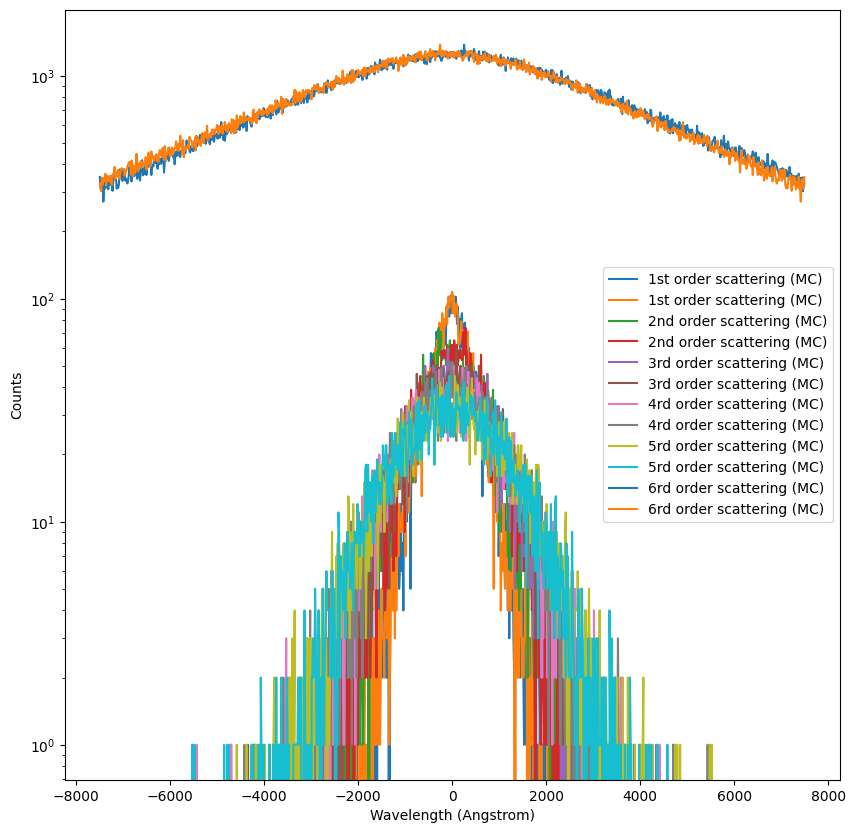

In [51]:

plt.figure(figsize=(10, 10))
for i, energy in enumerate(energies[1:]):
    velocities = ((bins[1:] + bins[:-1])/2 - centre) / centre * 3e5
    area =1# np.trapz(energy, velocities)
    plt.plot(velocities, energy/area, label=f"{i+1}{['st', 'nd', 'rd'][min(i, 2)]} order scattering (MC)")
    plt.plot(-velocities, energy/area, label=f"{i+1}{['st', 'nd', 'rd'][min(i, 2)]} order scattering (MC)")
#bins = np.linspace(-2500, 2500, 300) * u.km/u.s
with open("lineshapes.pickle", "rb") as f:
    lineshapes = pickle.load(f)
norm = np.trapz(lineshapes["f1"], lineshapes["vel"])
#plt.plot(lineshapes["vel"], lineshapes["f1"]/norm, color = "k", zorder=10, label="laor")
#plt.plot(lineshapes["vel"], lineshapes["f2"]/norm, color = "k", zorder=10)
#plt.plot(lineshapes["vel"], lineshapes["f3"]/norm, color = "k", zorder=10)
#plt.plot(lineshapes["vel"], lineshapes["f4"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f1"]/norm, color = "k", zorder=10, label="laor")
#plt.plot(-lineshapes["vel"], lineshapes["f2"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f3"]/norm, color = "k", zorder=10)
#plt.plot(-lineshapes["vel"], lineshapes["f4"]/norm, color = "k", zorder=10)
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Counts')
plt.yscale('log')
#plt.xlim(-3000, 3000)
#plt.ylim(1e-5, 1.1e-3)

In [ ]:
bins = np.linspace(-2500, 2500, 300) * u.km/u.s
with open("lineshapes.pickle", "rb") as f:
    lineshapes = pickle.load(f)
norm = np.trapz(lineshapes["f1"], lineshapes["vel"])
plt.plot(lineshapes["vel"], lineshapes["f1"]/norm, color = "C0")
plt.plot(lineshapes["vel"], lineshapes["f2"]/norm, color = "C1")
plt.plot(lineshapes["vel"], lineshapes["f3"]/norm, color = "C2")
plt.plot(lineshapes["vel"], lineshapes["f4"]/norm, color = "C3")
#plt.hist(velocities[interactions == 0], bins=bins, histtype='step', color='gray', label='no-scattering', density=True)
plt.hist(velocities[interactions == 1], bins=bins, histtype='step', color='C0', label='Single', density=True)
plt.hist(velocities[interactions == 2], bins=bins, histtype='step', color='C1', label='Double', density=True)
plt.hist(velocities[interactions == 3], bins=bins, histtype='step', color='C2', label='Tripple', density=True)
#plt.hist(velocities[interactions > 3], bins=bins, histtype='step', color='C3', label='>3', density=True)
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Counts')
plt.xlim(-2500, 2500)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad
import scipy
import astropy.units as u
import astropy.constants as consts


def j_of_x(x, beta):
    A = (1-beta**2)/(4*beta**2)
    x_min = (1-beta)/(1.+beta) if beta != -1 else 0
    x_max = (1+beta)/(1.-beta) if beta != 1 else 0
    return np.where((x >= x_min) & (x < 1),
                    A*((1+beta)*x - (1-beta)),
                    np.where((x >= 1) & (x < x_max),
                             A*((1+beta) - (1-beta)*x),
                             0.0))

# Seed profile f^(0)(v): a narrow Gaussian.
def seed_profile(v, env):
    witdh = env.vel * 1e3 * 1e2 # Convert from km/s to cm/s
    return scipy.stats.norm.pdf(v, loc=0, scale=witdh)

# Equation (5) as a double integration.
def scattering_convolution(v_range, f_prev, env):
    b = (2 * consts.k_B * env.temp_kelvin * u.K / consts.m_e).cgs.value
    factor = 4/(c.c.cgs.value*b**3*np.sqrt(np.pi))
    # Integrand: note x = (v-v')/c.
    def integrand(x,  beta, v):
        vinner = beta * 3e8
        return f_prev(v-x*3e8) * j_of_x(x, beta) * vinner**2 * np.exp(- (vinner/b)**2)
    # We assume f_prev is negligible outside [vmin, vmax]:
    f_vals = []
    for v in v_range:
            
        x_min = lambda beta: max(0,      (1+beta) / (1-beta))
        x_max = lambda beta: min(np.inf, (1+beta) / (1-beta))
        inner, err = dblquad(integrand, 0, 0.1, x_min, x_max, args=(v,))
        f_vals.append(inner)
    f_vals =  np.array(f_vals)
    tau = env.kappa * (env.R_outer - env.R_inner)
    return tau * factor * f_vals

def fn(v_grid, env, n):
    line_shapes = [seed_profile(v_grid, env)]
    for i in range(n):
        f_prev = scipy.interpolate.interp1d(v_grid, line_shapes[-1], kind='cubic', fill_value=0, bounds_error=False)
        line_shapes.append(scattering_convolution(v_grid, f_prev, env))
    return line_shapes

# Example usage:
env = Environment(temp_kelvin=1e4)
v_vals = np.linspace(-3e8, 3e8, 100)  # v in cm/s (approx. -3000 to 3000 km/s)
f1_vals = fn(v_vals, env, 1)

plt.plot(v_vals/1e5, f1_vals[0])
plt.plot(v_vals/1e5, f1_vals[1])
plt.xlabel("Velocity (km/s)")
plt.ylabel(r"$f^{(1)}(v)$")
plt.title("Profile after one scattering (Eq. 5)")
plt.yscale('log')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad, quad
import scipy
import astropy.units as u
import astropy.constants as consts
import numba

@numba.njit
def j_of_x(x, beta):
    A = (1-beta**2)/(4*beta**2)
    x_min = (1-beta)/(1.+beta) if beta != -1 else 0
    x_max = (1+beta)/(1.-beta) if beta != 1 else 0
    return np.where((x >= x_min) & (x < 1),
                    A*((1+beta)*x - (1-beta)),
                    np.where((x >= 1) & (x < x_max),
                             A*((1+beta) - (1-beta)*x),
                             0.0))

# Seed profile f^(0)(v): a narrow Gaussian.
def seed_profile(v, env):
    witdh = env.vel * 1e3 * 1e2 # Convert from km/s to cm/s
    return scipy.stats.norm.pdf(v, loc=0, scale=witdh)

# Equation (5) as a double integration.
def scattering_convolution(v_range, f_prev, env):
    b = (2 * consts.k_B * env.temp_kelvin * u.K / consts.m_e).cgs.value
    factor = 4/(c.c.cgs.value*b**3*np.sqrt(np.pi))
    # Integrand: note x = (v-v')/c.
    def integrand(beta, x):
        vinner = beta * 3e8
        return j_of_x(x, beta) * vinner**2 * np.exp(- (vinner/b)**2)
    
    def j_t(x, v):
        #x_min = max(0, (1-beta) / (1+beta))
        #x_max = min(1, (1+beta) / (1-beta))
        integral_val = quad(integrand, 0, 0.1, args=(x, ))[0]
        return f_prev(v-x*3e8) * integral_val
    # We assume f_prev is negligible outside [vmin, vmax]:
    f_vals = []
    for v in v_range:
        inner, err = quad(j_t, v-0.1, v+0.1, args=(v,))
        print(v, inner)
        f_vals.append(inner)
    f_vals =  np.array(f_vals)
    tau = env.kappa * (env.R_outer - env.R_inner)
    return tau * factor * f_vals

def fn(v_grid, env, n):
    line_shapes = [seed_profile(v_grid, env)]
    for i in range(n):
        f_prev = scipy.interpolate.interp1d(v_grid, line_shapes[-1], kind='linear', fill_value=0, bounds_error=False)
        line_shapes.append(scattering_convolution(v_grid, f_prev, env))
    return line_shapes

# Example usage:
env = Environment(temp_kelvin=1e4)
v_vals = np.linspace(-3e7, 3e7, 30)  # v in cm/s (approx. -3000 to 3000 km/s)
f1_vals = fn(v_vals, env, 1)

plt.plot(v_vals/1e5, f1_vals[0])
plt.plot(v_vals/1e5, f1_vals[1])
plt.xlabel("Velocity (km/s)")
plt.ylabel(r"$f^{(1)}(v)$")
plt.title("Profile after one scattering (Eq. 5)")
plt.yscale('log')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad, quad
import scipy
import astropy.units as u
import astropy.constants as consts
import numba

@numba.njit
def j_of_x(x, beta):
    A = (1-beta**2)/(4*beta**2)
    x_min = (1-beta)/(1.+beta) if beta != -1 else 0
    x_max = (1+beta)/(1.-beta) if beta != 1 else 0
    return np.where((x >= x_min) & (x < 1),
                    A*((1+beta)*x - (1-beta)),
                    np.where((x >= 1) & (x < x_max),
                             A*((1+beta) - (1-beta)*x),
                             0.0))

# Seed profile f^(0)(v): a narrow Gaussian.
def seed_profile(v, env):
    witdh = env.vel * 1e3 * 1e2 # Convert from km/s to cm/s
    return scipy.stats.norm.pdf(v, loc=0, scale=witdh)

# Equation (5) as a double integration.
def scattering_convolution(v_range, f_prev, env):
    b = (2 * consts.k_B * env.temp_kelvin * u.K / consts.m_e).cgs.value**0.5
    c = consts.c.cgs.value
    tau = env.kappa * (env.R_outer - env.R_inner)
    factor = 4*tau*c**4/(b**3*np.sqrt(np.pi))
    # Integrand: note x = (v-v')/c.
    def integrand(x, beta, v):
        return f_prev(v-x*c) * j_of_x(x+1, beta) * beta**2 * np.exp(- (beta*c/b)**2)
    
    # We assume f_prev is negligible outside [vmin, vmax]:
    f_vals = []
    for v in v_range:
        x_min = lambda beta: (1-beta) / (1+beta)
        x_max = lambda beta: (1+beta) / (1-beta)
        inner, err = dblquad(integrand, 0, 1, x_min, x_max, args=(v,))
        f_vals.append(inner)
    f_vals =  np.array(f_vals)
    return tau * factor * f_vals

def fn(v_grid, env, n):
    line_shapes = [seed_profile(v_grid, env)]
    for i in range(n):
        f_prev = scipy.interpolate.interp1d(v_grid, line_shapes[-1], kind='linear', fill_value=0, bounds_error=False)
        line_shapes.append(scattering_convolution(v_grid, f_prev, env))
    return line_shapes

# Example usage:
env = Environment(temp_kelvin=1e4)
v_vals = np.linspace(-1e7, 1e7, 100)  # v in cm/s (approx. -3000 to 3000 km/s)
f1_vals = fn(v_vals, env, 1)

plt.plot(v_vals/1e5, f1_vals[0])
plt.plot(v_vals/1e5, f1_vals[1])
plt.xlabel("Velocity (km/s)")
plt.ylabel(r"$f^{(1)}(v)$")
plt.title("Profile after one scattering (Eq. 5)")
plt.yscale('log')
plt.show()

In [ ]:
10000000.0 

In [ ]:
10000000.0 